Starting carbon footprint tracking and model training...
Preprocessing: Tenure calculation and categorical encoding...
Initial class distribution: {0: 166, 1: 82}
Post-SMOTE class distribution: {0: 166, 1: 166}

Hyperparameter optimization via Cross-Validation...
Optimal hyperparameters identified: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 200}

--- Final Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.73      0.78        41
           1       0.59      0.73      0.65        22

    accuracy                           0.73        63
   macro avg       0.71      0.73      0.72        63
weighted avg       0.75      0.73      0.74        63


Computing SHAP values for model transparency...


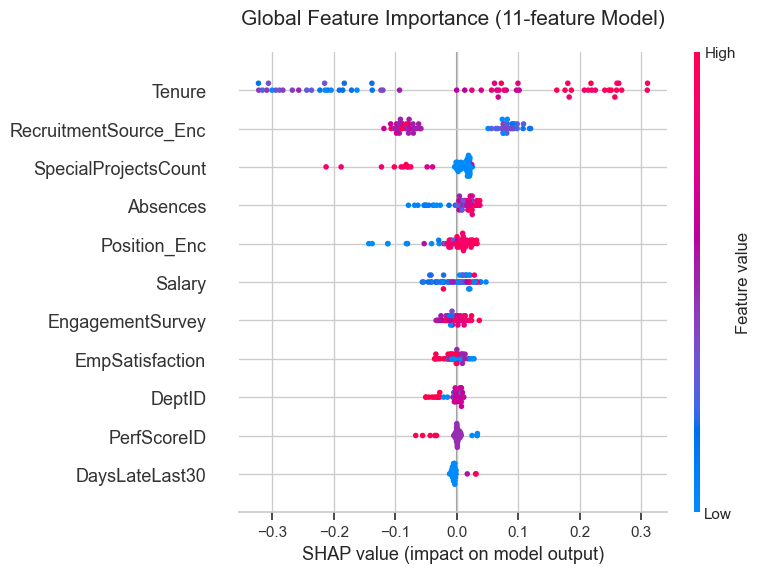

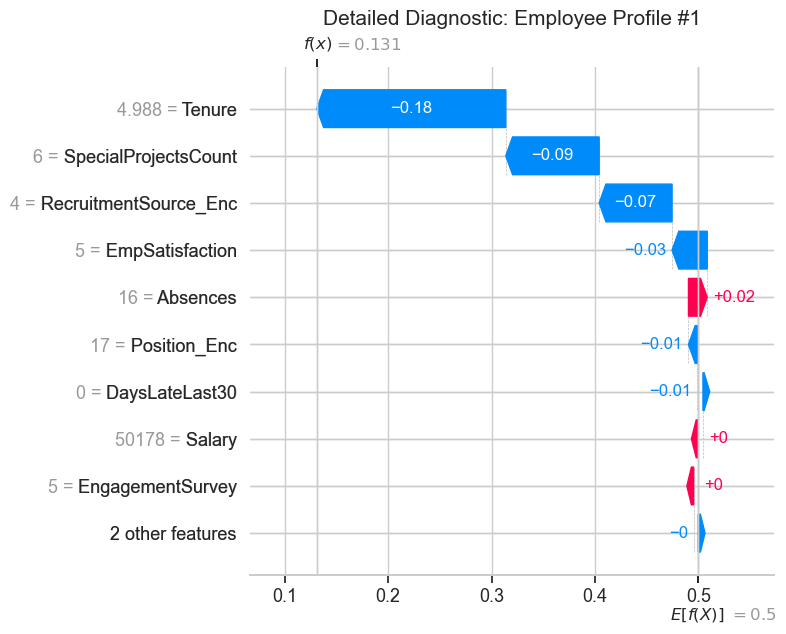


Exporting model, encoders, and SHAP explainer for deployment...

Processing complete. Sustainability report generated: 'emissions_ml.csv'


In [1]:
import pandas as pd
import warnings
import os
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import shap
from codecarbon import EmissionsTracker
import logging
from imblearn.over_sampling import SMOTE 

# Global logging and warning configuration
logging.getLogger("codecarbon").setLevel(logging.ERROR)
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Carbon tracker cleanup and initialization
try:
    if 'tracker' in locals() or 'tracker' in globals():
        tracker.stop()
except Exception:
    pass

tracker = EmissionsTracker(
    project_name="Guardian_AI_Final_Training",
    output_file="emissions_ml.csv",
    log_level="error" 
)
tracker.start()
print("Starting carbon footprint tracking and model training...")

# Load anonymized dataset
df_anon = pd.read_csv('HR_anonymized.csv')

print("Preprocessing: Tenure calculation and categorical encoding...")

# 1. Feature Engineering: Calculate Tenure (years) from DateofHire
df_anon['DateofHire'] = pd.to_datetime(df_anon['DateofHire'])
ref_date = pd.to_datetime('2020-01-01')  # Dataset reference date
df_anon['Tenure'] = (ref_date - df_anon['DateofHire']).dt.days / 365.25

# 2. Categorical encoding for textual variables
le_source = LabelEncoder()
df_anon['RecruitmentSource_Enc'] = le_source.fit_transform(df_anon['RecruitmentSource'])

le_pos = LabelEncoder()
df_anon['Position_Enc'] = le_pos.fit_transform(df_anon['Position'])

# 3. Final feature selection (11 variables)
features = [
    'Salary', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 
    'Absences', 'DaysLateLast30', 'DeptID', 'PerfScoreID',
    'Tenure', 'RecruitmentSource_Enc', 'Position_Enc'
]

X = df_anon[features]
y = df_anon['Termd'] 

# 4. Dataset splitting (Train/Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Class balancing via SMOTE (applied to Training set only)
print(f"Initial class distribution: {dict(pd.Series(y_train).value_counts())}")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"Post-SMOTE class distribution: {dict(pd.Series(y_train_res).value_counts())}")


print("\nHyperparameter optimization via Cross-Validation...")

# Initialize Random Forest with class weight balancing
rf_base = RandomForestClassifier(random_state=42, class_weight="balanced")

# Hyperparameter grid definition
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [10, 15],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt']
}

# n_jobs=1 used for Windows environment compatibility
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, 
                           cv=5, scoring='f1', n_jobs=1)
grid_search.fit(X_train_res, y_train_res)

# Extract best estimator
model = grid_search.best_estimator_

print(f"Optimal hyperparameters identified: {grid_search.best_params_}")

# Performance evaluation on the test set
y_pred = model.predict(X_test)
print("\n--- Final Classification Report ---")
print(classification_report(y_test, y_pred))

print("\nComputing SHAP values for model transparency...")
explainer = shap.TreeExplainer(model)
shap_values_all = explainer(X_test)

# Isolate SHAP values for the positive class (Turnover/Termination)
if len(shap_values_all.shape) == 3:
    shap_exp = shap_values_all[:, :, 1]
else:
    shap_exp = shap_values_all

# 1. Global Importance: Beeswarm Plot
# Visualizing feature impact distribution across the test set
plt.figure(figsize=(12, 8))
plt.title("Global Feature Importance (11-feature Model)", fontsize=15, pad=20)
shap.plots.beeswarm(shap_exp, max_display=12, show=False)
plt.tight_layout()
plt.savefig('shap_beeswarm_pro.png', dpi=300)
plt.show()

# 2. Individual Analysis: Waterfall Plot
# Explaining the logic for a specific employee instance (e.g., index 1)
# Critical for demonstrating AI Agent reasoning during the defense
sample_idx = 1 
plt.figure(figsize=(12, 6))
plt.title(f"Detailed Diagnostic: Employee Profile #{sample_idx}", fontsize=15, pad=30)
shap.plots.waterfall(shap_exp[sample_idx], max_display=10, show=False)
plt.tight_layout()
plt.savefig('shap_waterfall_pro.png', dpi=300)
plt.show()

print("\nExporting model, encoders, and SHAP explainer for deployment...")
joblib.dump(model, 'rf_model.joblib')
joblib.dump(le_source, 'le_source.joblib')
joblib.dump(le_pos, 'le_pos.joblib')
joblib.dump(explainer, 'shap_explainer.joblib')

# Finalize carbon footprint assessment
tracker.stop()
print("\nProcessing complete. Sustainability report generated: 'emissions_ml.csv'")